# Notebook 3 — BiLSTM (PyTorch) for Multi-label Toxic Comments

**Purpose.** Train a simple neural baseline using a word-level BiLSTM:
- Build a word vocab from **Train only**
- Convert texts → integer ids, pad/truncate to a fixed length
- Model: Embedding → BiLSTM → mean+max pooling → Linear(6) → sigmoid
- Loss: BCEWithLogits (multi-label). We’ll add `pos_weight` from Train to help rare labels
- Tune **per-label thresholds** on Validation, then evaluate on Test

**Inputs.** `/content/drive/MyDrive/Colab_Notebooks/Assignment 3/processed/{train,val,test}.csv`, `meta.json`  
**Outputs.** Figures → `figures/`, metrics JSON → `metrics/metrics_bilstm.json`, optional artifacts → `artifacts_bilstm/`

**Notebook link**:
https://colab.research.google.com/drive/1fthqt1gtbcs6hkN__ZHl5GHKcFonriQw?usp=sharing

In [1]:
# mount drive and set paths
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/Colab_Notebooks/Assignment 3"
PROC = f"{BASE}/processed"
FIGS = f"{BASE}/figures"
METR = f"{BASE}/metrics"
ART  = f"{BASE}/artifacts_bilstm"

import os, json, random, numpy as np, pandas as pd
os.makedirs(FIGS, exist_ok=True)
os.makedirs(METR, exist_ok=True)
os.makedirs(ART, exist_ok=True)

print("BASE:", BASE)

Mounted at /content/drive
BASE: /content/drive/MyDrive/Colab_Notebooks/Assignment 3


In [2]:
import re, math, time
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import f1_score, average_precision_score, hamming_loss, precision_recall_curve

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

plt.style.use("seaborn-v0_8-whitegrid")
print("device:", device)

device: cuda


## What is a BiLSTM text classifier
**Plain idea.** An LSTM reads a sentence **token by token** and keeps a memory of what it has seen.  
A **BiLSTM** runs this in **both directions** (left→right and right←left), so each word’s representation can use **past and future** context from the sentence.

### How our pipeline works
1. **Tokenisation (simple):** we split on whitespace (using the already-cleaned text from Notebook 1).  
2. **Vocabulary (Train-only):** build a word→id map from the **training** texts (avoid leakage). Unknown words map to `<unk>`.  
3. **Vectorisation:** convert each sentence to a list of ids, then **pad/truncate** to a fixed length (e.g., `max_len=200`).  
4. **Embedding layer:** learns a dense vector for each token id (randomly initialised; trained with the model).  
5. **BiLSTM encoder:** processes the sequence forward and backward. We then take **mean-pooling + max-pooling** over time and **concatenate** them to get one sentence vector.  
6. **Classifier head:** a linear layer maps that vector to **6 logits** (one per label), followed by **sigmoid** at evaluation time to get probabilities.

### Why multi-label (not softmax)
Our six toxicity labels are **not mutually exclusive** (e.g., a comment can be *toxic* and *insult*).  
We therefore use **6 independent sigmoids** and train with:
- **`BCEWithLogitsLoss`** (stable numerics for sigmoid + cross-entropy in one op)  
- **`pos_weight = (neg/pos)` per label** computed from **Train** to help with class imbalance (rare labels like `threat`, `identity_hate`).

### From probabilities to decisions
- A single **0.5** threshold is usually suboptimal on imbalanced data.  
- We **tune a threshold per label on Validation** to maximise **F1**. This typically improves **Macro-F1** and fairness.

### Training setup (simple and reproducible)
- **Embedding dim** ≈ 100, **hidden size** ≈ 128, **dropout** ≈ 0.3  
- **Max length** = 200 tokens (from length stats in Notebook 1)  
- **Optimiser** = Adam, small LR (e.g., `1e-3`)  
- **Epochs** = ~4 (fast to train, good baseline)  
- **Batches**: modest sizes so it runs on CPU if needed

### What we report (and why)
- **Micro-F1** (overall), **Macro-F1** (treats each label equally),  
- **Per-label F1** and **Per-label PR-AUC** (plus **Mean PR-AUC**) for threshold-free quality,  
- **Hamming Accuracy** (label-wise accuracy; aligns with the assignment’s accuracy note).

### Strengths and limitations (honest view)
- **Strengths:** simple, fast, learns word order; a solid **neural baseline** vs. TF-IDF+SVM.  
- **Limitations:** fixed vocab → **OOV** issues; weaker at long-range dependencies and nuanced context than transformer models (e.g., DistilBERT); performance depends on the chosen `max_len` and training data size.

The BiLSTM gives us a fair neural baseline that understands **sequence order** and is easy to train. With `pos_weight` and per-label threshold tuning, it’s competitive—but we expect **DistilBERT** to do better on **context-heavy** and **rare** labels.

## Load splits and metadata

We reuse the exact same Train/Val/Test to keep comparisons fair. We also read the text column and label names from `meta.json`.

In [3]:
with open(f"{PROC}/meta.json","r") as f:
    meta = json.load(f)
LABELS = meta["labels"]
TEXT_COL = meta["text_col"]

train_df = pd.read_csv(f"{PROC}/train.csv")
val_df   = pd.read_csv(f"{PROC}/val.csv")
test_df  = pd.read_csv(f"{PROC}/test.csv")

print("Text:", TEXT_COL)
print("Labels:", LABELS)
print("sizes:", len(train_df), len(val_df), len(test_df))

Text: comment_text
Labels: ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
sizes: 127430 15929 15929


## Tokenisation and vocabulary

**Why simple tokenisation?** We already cleaned text in Notebook 1; a whitespace split is enough for a baseline and keeps this model easy to understand.

**Vocabulary build (Train-only).**
- Count tokens on **Train** to avoid test leakage.
- Keep words with frequency ≥ `min_freq` (here **2**) and cap to **30k** most frequent.
- Reserve special ids: `<pad>=0`, `<unk>=1`.

This gives us a compact **word→id** map (`stoi`) and the reverse (`itos`) for inspection.

In [4]:
def simple_tokenize(s):
    return str(s).split()

def build_vocab(texts, min_freq=2, max_size=30000):
    freq = Counter()
    for t in texts:
        freq.update(simple_tokenize(t))
    # keep tokens that appear at least min_freq
    toks = [w for w,c in freq.items() if c >= min_freq]
    # sort by frequency
    toks.sort(key=lambda w: -freq[w])
    if max_size:
        toks = toks[:max_size]
    stoi = {"<pad>":0, "<unk>":1}
    for i,w in enumerate(toks, start=2):
        stoi[w] = i
    itos = {i:w for w,i in stoi.items()}
    return stoi, itos, freq

train_texts = train_df[TEXT_COL].astype(str).tolist()
stoi, itos, freq = build_vocab(train_texts, min_freq=2, max_size=30000)
vocab_size = len(stoi)
print("vocab_size:", vocab_size, "| examples of tokens:", list(stoi)[:10])

vocab_size: 30002 | examples of tokens: ['<pad>', '<unk>', 'the', 'to', 'of', 'and', 'a', 'i', 'you', 'is']


## Encode sentences and build DataLoaders

For each comment:
- Convert tokens to ids using the vocab; unknowns → `<unk>`.
- **Pad/truncate to `max_len=200`** so every batch has the same shape.
- We keep **batch sizes modest** so it can run on CPU if needed.

We wrap everything in a small `Dataset` and build `DataLoader`s for Train/Val/Test.

In [5]:
MAX_LEN = 200
BATCH_TRAIN = 64 if device=="cuda" else 32
BATCH_EVAL  = 128 if device=="cuda" else 64

def encode_text(s, stoi, max_len=200):
    ids = [stoi.get(w, 1) for w in simple_tokenize(s)]
    if len(ids) < max_len:
        ids = ids + [0]*(max_len - len(ids))
    else:
        ids = ids[:max_len]
    return np.array(ids, dtype=np.int64)

class TextSet(Dataset):
    def __init__(self, frame, text_col, label_cols, stoi, max_len):
        self.texts = frame[text_col].astype(str).tolist()
        self.labels = frame[label_cols].astype(int).values
        self.stoi = stoi
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        x = encode_text(self.texts[i], self.stoi, self.max_len)
        y = self.labels[i].astype(np.float32)
        return torch.from_numpy(x), torch.from_numpy(y)

train_ds = TextSet(train_df, TEXT_COL, LABELS, stoi, MAX_LEN)
val_ds   = TextSet(val_df,   TEXT_COL, LABELS, stoi, MAX_LEN)
test_ds  = TextSet(test_df,  TEXT_COL, LABELS, stoi, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_TRAIN, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_EVAL, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_EVAL, shuffle=False, drop_last=False)

len(train_ds), len(val_ds), len(test_ds)

(127430, 15929, 15929)

## Model architecture (BiLSTM with pooling)

**Block diagram.**  
`Embedding( vocab_size → 100 ) → BiLSTM( hidden=128 ) → [mean-pool, max-pool] → concat → Dropout(0.3) → Linear( 256*2 → 6 logits )`

**Why mean + max pooling?**  
- *Mean* summarises overall context; *max* catches the strongest cue in the sequence.  
- Concatenating both is a cheap way to capture complementary information.

In [6]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden=128, num_labels=6, pad_idx=0, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden*2*2, num_labels)  # biLSTM (2*hidden), mean+max pooled -> concat (x2)
    def forward(self, x):
        x = self.emb(x)               # [B, T, E]
        out, _ = self.lstm(x)         # [B, T, 2H]
        mean_pool = out.mean(dim=1)   # [B, 2H]
        max_pool, _ = out.max(dim=1)  # [B, 2H]
        h = torch.cat([mean_pool, max_pool], dim=1)
        h = self.drop(h)
        logits = self.fc(h)           # [B, L]
        return logits

num_labels = len(LABELS)
model = BiLSTM(vocab_size=vocab_size, embed_dim=100, hidden=128, num_labels=num_labels, pad_idx=0, dropout=0.3).to(device)
print(model)

BiLSTM(
  (emb): Embedding(30002, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=6, bias=True)
)


## Loss, class imbalance, and optimiser

**Multi-label loss.** We use **`BCEWithLogitsLoss`** (sigmoid built-in), one logit per label.  
**Imbalance handling.** Compute **`pos_weight = (neg / pos)`** from **Train** per label to up-weight rare positives (e.g., `threat`, `identity_hate`).  
**Optimiser.** Adam with a small learning rate (**1e-3**) works well for this size.

In [7]:
# pos_weight = neg/pos from TRAIN
pos_counts = train_df[LABELS].sum().values.astype(np.float32)
neg_counts = (len(train_df) - pos_counts).astype(np.float32)
pos_weight = torch.tensor((neg_counts / (pos_counts + 1e-8)).clip(max=50.0), dtype=torch.float32).to(device)
print("pos_weight:", np.round(pos_weight.cpu().numpy(), 2))

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # start simple

pos_weight: [ 9.46 50.   17.98 50.   19.24 50.  ]


## Training loop (transparent)

We train for **50 epochs** and record the batch loss so we can plot a simple convergence curve.  
No fancy tricks here (no gradient accumulation, no scheduler) to keep the baseline easy to reproduce.

In [8]:
def sigmoid_np(x): return 1 / (1 + np.exp(-x))

EPOCHS = 50
train_losses = []

for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    nsteps = 0
    t0 = time.time()
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running += loss.item()
        nsteps += 1
        train_losses.append(loss.item())
    dt = time.time() - t0
    print(f"epoch {epoch} | train_loss={running/max(1,nsteps):.4f} | {dt:.1f}s")

epoch 1 | train_loss=0.5018 | 13.6s
epoch 2 | train_loss=0.3063 | 12.7s
epoch 3 | train_loss=0.2442 | 12.7s
epoch 4 | train_loss=0.2044 | 12.6s
epoch 5 | train_loss=0.1760 | 12.7s
epoch 6 | train_loss=0.1513 | 12.6s
epoch 7 | train_loss=0.1347 | 12.6s
epoch 8 | train_loss=0.1213 | 12.7s
epoch 9 | train_loss=0.1091 | 12.7s
epoch 10 | train_loss=0.0994 | 12.6s
epoch 11 | train_loss=0.0921 | 12.6s
epoch 12 | train_loss=0.0847 | 12.7s
epoch 13 | train_loss=0.0810 | 12.7s
epoch 14 | train_loss=0.0748 | 12.7s
epoch 15 | train_loss=0.0710 | 12.7s
epoch 16 | train_loss=0.0682 | 12.7s
epoch 17 | train_loss=0.0630 | 12.7s
epoch 18 | train_loss=0.0575 | 12.7s
epoch 19 | train_loss=0.0556 | 12.6s
epoch 20 | train_loss=0.0540 | 12.6s
epoch 21 | train_loss=0.0497 | 12.7s
epoch 22 | train_loss=0.0474 | 12.6s
epoch 23 | train_loss=0.0448 | 12.7s
epoch 24 | train_loss=0.0427 | 12.7s
epoch 25 | train_loss=0.0413 | 12.7s
epoch 26 | train_loss=0.0375 | 12.6s
epoch 27 | train_loss=0.0381 | 12.7s
epoch 28 |

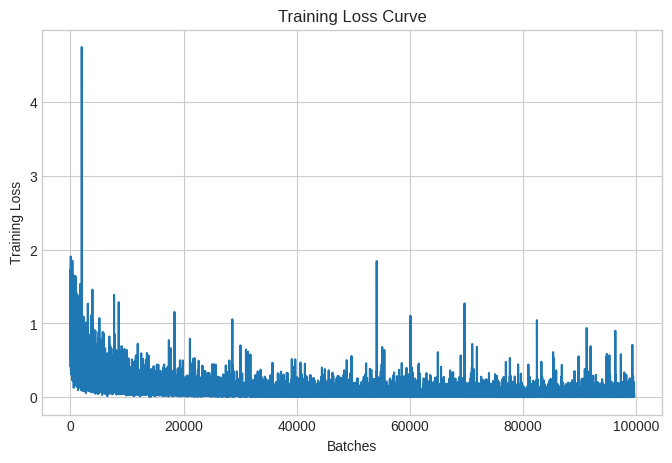

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.xlabel("Batches")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.show()

## Validation → per-label threshold tuning

The model outputs **probabilities** per label. Converting to 0/1 requires thresholds:
- A fixed **0.5** is often **not optimal** on imbalanced data.
- We therefore **sweep thresholds on Validation** and pick the value that **maximises F1** for each label.
This step usually boosts **Macro-F1** (treats rare labels fairly).

In [10]:
# collect val probs
model.eval()
val_probs = []
val_y = val_df[LABELS].values.astype(int)
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        val_probs.append(torch.sigmoid(logits).cpu().numpy())
val_probs = np.vstack(val_probs)

def tune_thresholds_by_f1(y_true, y_prob, grid=None):
    if grid is None: grid = np.linspace(0.05, 0.95, 19)
    K = y_true.shape[1]
    thr = np.zeros(K, dtype=float)
    bestf = np.zeros(K, dtype=float)
    for k in range(K):
        yk = y_true[:,k]; pk = y_prob[:,k]
        best_t, best = 0.5, 0.0
        for t in grid:
            pred = (pk >= t).astype(int)
            f1 = f1_score(yk, pred, zero_division=0)
            if f1 > best:
                best, best_t = f1, t
        thr[k], bestf[k] = best_t, best
    return thr, bestf

bilstm_thr, val_f1s = tune_thresholds_by_f1(val_y, val_probs)
print("val thresholds:")
for lab, t, f1 in zip(LABELS, bilstm_thr, val_f1s):
    print(f"{lab:14s} t*={t:.2f}  F1@Val={f1:.3f}")

val thresholds:
toxic          t*=0.95  F1@Val=0.715
severe_toxic   t*=0.15  F1@Val=0.408
obscene        t*=0.95  F1@Val=0.764
threat         t*=0.65  F1@Val=0.456
insult         t*=0.80  F1@Val=0.658
identity_hate  t*=0.85  F1@Val=0.380


## Test evaluation (tuned thresholds)

We report:
- **Micro-F1** (overall) and **Macro-F1** (equal weight per label)  
- **Per-label F1** for detailed strengths/weaknesses  
- **Per-label PR-AUC** and **Mean PR-AUC** (threshold-free quality; robust under imbalance)  
- **Hamming Accuracy** (label-wise correctness; aligns with the assignment’s accuracy note)

In [11]:
# probs on test
test_probs = []
test_y = test_df[LABELS].values.astype(int)

model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        test_probs.append(torch.sigmoid(logits).cpu().numpy())
test_probs = np.vstack(test_probs)

test_pred = (test_probs >= bilstm_thr).astype(int)

micro_f1 = f1_score(test_y, test_pred, average="micro", zero_division=0)
macro_f1 = f1_score(test_y, test_pred, average="macro", zero_division=0)
per_f1   = [f1_score(test_y[:,i], test_pred[:,i], zero_division=0) for i in range(len(LABELS))]
per_ap   = [average_precision_score(test_y[:,i], test_probs[:,i]) for i in range(len(LABELS))]
mean_ap  = float(np.mean(per_ap))
hamm_acc = 1.0 - hamming_loss(test_y, test_pred)

print("BiLSTM — Test (tuned thresholds)")
print(f"Micro-F1: {micro_f1:.3f}")
print(f"Macro-F1: {macro_f1:.3f}")
print(f"Mean PR-AUC: {mean_ap:.3f}")
print(f"Hamming Accuracy: {hamm_acc:.3f}")

pd.DataFrame({"Label": LABELS, "F1": np.round(per_f1,3), "PR-AUC": np.round(per_ap,3)})

BiLSTM — Test (tuned thresholds)
Micro-F1: 0.674
Macro-F1: 0.567
Mean PR-AUC: 0.555
Hamming Accuracy: 0.976


,Label,F1,PR-AUC
0,toxic,0.722,0.793
1,severe_toxic,0.409,0.389
2,obscene,0.745,0.799
3,threat,0.500,0.393
4,insult,0.654,0.665
5,identity_hate,0.374,0.288


## PR curves for two hard labels

We show PR curves for `severe_toxic` and `threat` (these are often rare).

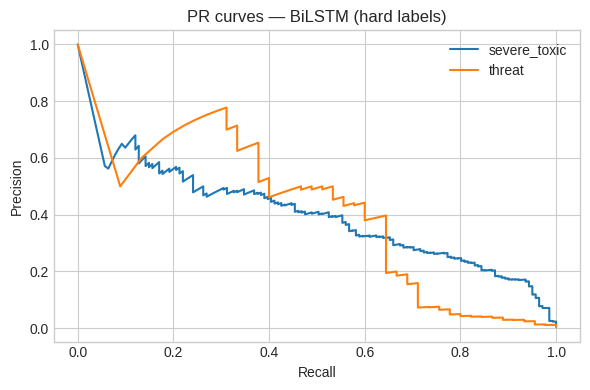

In [12]:
hard = ["severe_toxic","threat"]
plt.figure(figsize=(6,4))
for lab in hard:
    k = LABELS.index(lab)
    p, r, _ = precision_recall_curve(test_y[:,k], test_probs[:,k])
    plt.plot(r, p, label=lab)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR curves — BiLSTM (hard labels)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGS}/bilstm_pr_curves.png", dpi=150)
plt.show()

## Save metrics (for the final comparison table in Notebook 4)

We write a small JSON so the DistilBERT notebook can aggregate all models.

In [13]:
import datetime, json, os

bilstm_metrics = {
    "model": "BiLSTM",
    "params": {"embed_dim": 100, "hidden": 128, "max_len": MAX_LEN, "epochs": 4},
    "micro_f1": float(micro_f1),
    "macro_f1": float(macro_f1),
    "mean_pr_auc": float(mean_ap),
    "hamming_acc": float(hamm_acc),
    "per_label": {lab: {"f1": float(f), "ap": float(ap)} for lab,f,ap in zip(LABELS, per_f1, per_ap)},
    "thresholds": {lab: float(t) for lab,t in zip(LABELS, bilstm_thr)},
    "created_at": datetime.datetime.now().isoformat(timespec="seconds")
}
with open(f"{METR}/metrics_bilstm.json","w") as f:
    json.dump(bilstm_metrics, f, indent=2)
print("saved:", f"{METR}/metrics_bilstm.json")

saved: /content/drive/MyDrive/Colab_Notebooks/Assignment 3/metrics/metrics_bilstm.json
